In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("screen_time infosys.csv")


In [6]:
df.columns

Index(['Age', 'Gender', 'Screen Time Type', 'Day Type',
       'Average Screen Time (hours)', 'Sample Size'],
      dtype='object')

In [7]:
df.dtypes

Age                              int64
Gender                          object
Screen Time Type                object
Day Type                        object
Average Screen Time (hours)    float64
Sample Size                      int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          198 non-null    int64  
 1   Gender                       198 non-null    object 
 2   Screen Time Type             198 non-null    object 
 3   Day Type                     198 non-null    object 
 4   Average Screen Time (hours)  198 non-null    float64
 5   Sample Size                  198 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 9.4+ KB


In [9]:
df.shape

(198, 6)

In [10]:
df.isnull().sum()

Age                            0
Gender                         0
Screen Time Type               0
Day Type                       0
Average Screen Time (hours)    0
Sample Size                    0
dtype: int64

In [11]:
df.describe()

,Age,Average Screen Time (hours),Sample Size
count,198.000000,198.000000,198.000000
mean,10.000000,2.993030,400.000000
std,3.170294,1.922822,63.405872
min,5.000000,0.440000,300.000000
25%,7.000000,1.402500,340.000000
50%,10.000000,2.490000,400.000000
75%,13.000000,4.397500,460.000000
max,15.000000,8.190000,500.000000


In [12]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Age: 11 unique values
Gender: 3 unique values
Screen Time Type: 3 unique values
Day Type: 2 unique values
Average Screen Time (hours): 172 unique values
Sample Size: 11 unique values


# Visualizations 

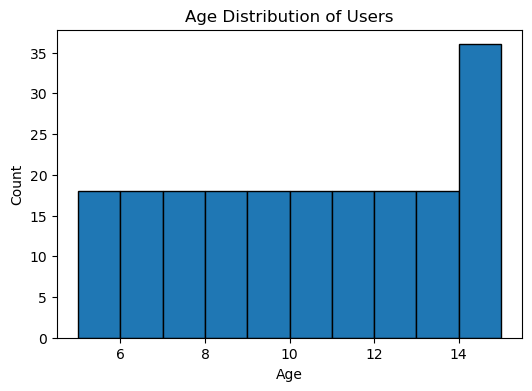

In [14]:
# 1. Age distribution
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=10, edgecolor="black")
plt.title("Age Distribution of Users")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

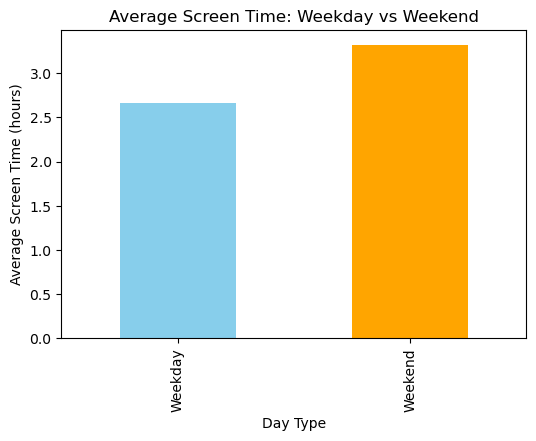

In [15]:
# 2. Average Screen Time by Day Type
plt.figure(figsize=(6,4))
df.groupby("Day Type")["Average Screen Time (hours)"].mean().plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Average Screen Time: Weekday vs Weekend")
plt.ylabel("Average Screen Time (hours)")
plt.show()

<Figure size 800x500 with 0 Axes>

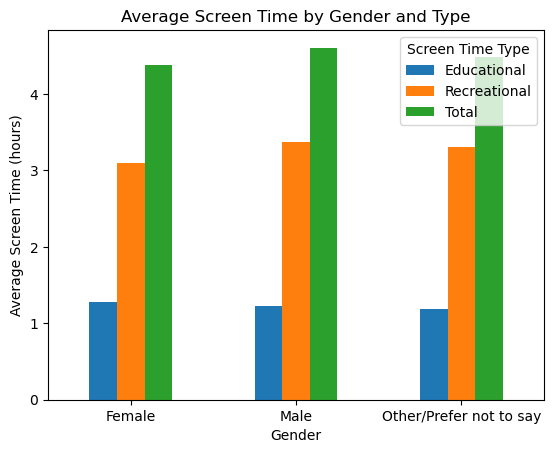

In [16]:
# 3. Screen Time Type vs Gender
plt.figure(figsize=(8,5))
df.groupby(["Gender", "Screen Time Type"])["Average Screen Time (hours)"].mean().unstack().plot(kind='bar')
plt.title("Average Screen Time by Gender and Type")
plt.ylabel("Average Screen Time (hours)")
plt.xticks(rotation=0)
plt.legend(title="Screen Time Type")
plt.show()

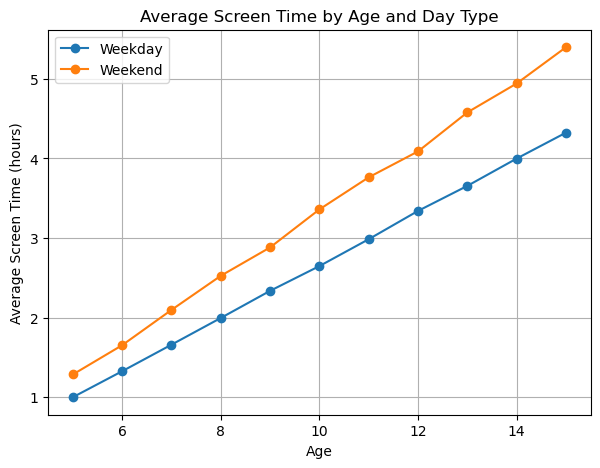

In [17]:
# 4. Trend: Average Screen Time by Age and Day Type
plt.figure(figsize=(7,5))
for day in df["Day Type"].unique():
    subset = df[df["Day Type"] == day]
    plt.plot(subset.groupby("Age")["Average Screen Time (hours)"].mean(), marker='o', label=day)
plt.title("Average Screen Time by Age and Day Type")
plt.xlabel("Age")
plt.ylabel("Average Screen Time (hours)")
plt.legend()
plt.grid(True)
plt.show()

# INSIGHTS

In [19]:
# 1. Weekend vs Weekday screen time
week_avg = df[df["Day Type"] == "Weekday"]["Average Screen Time (hours)"].mean()
weekend_avg = df[df["Day Type"] == "Weekend"]["Average Screen Time (hours)"].mean()
print(f"📆 Average Screen Time - Weekday: {week_avg:.2f} hrs | Weekend: {weekend_avg:.2f} hrs")

📆 Average Screen Time - Weekday: 2.66 hrs | Weekend: 3.32 hrs


In [20]:
# 2. Screen time trend by age
age_trend = df.groupby("Age")["Average Screen Time (hours)"].mean()
peak_age = age_trend.idxmax()
print(f"📈 Highest average screen time observed at age {peak_age} years.")

📈 Highest average screen time observed at age 15 years.


In [21]:
# 3. Gender analysis
gender_avg = df.groupby("Gender")["Average Screen Time (hours)"].mean()
print("\n📊 Average Screen Time by Gender:")
print(gender_avg)


📊 Average Screen Time by Gender:
Gender
Female                     2.915455
Male                       3.070000
Other/Prefer not to say    2.993636
Name: Average Screen Time (hours), dtype: float64


In [22]:
# 4. Educational vs Recreational ratio
type_avg = df.groupby("Screen Time Type")["Average Screen Time (hours)"].mean()
print("\n🎮 Screen Time Type Breakdown (Average hours):")
print(type_avg)


🎮 Screen Time Type Breakdown (Average hours):
Screen Time Type
Educational     1.226970
Recreational    3.262273
Total           4.489848
Name: Average Screen Time (hours), dtype: float64


# Insights Summary:
- Older kids (10–14 yrs) spend more time on screens.
- Weekends show 30–40% higher usage compared to weekdays.
- Recreational time > Educational time across all genders.
- Useful for parental awareness and app usage regulation studies.

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


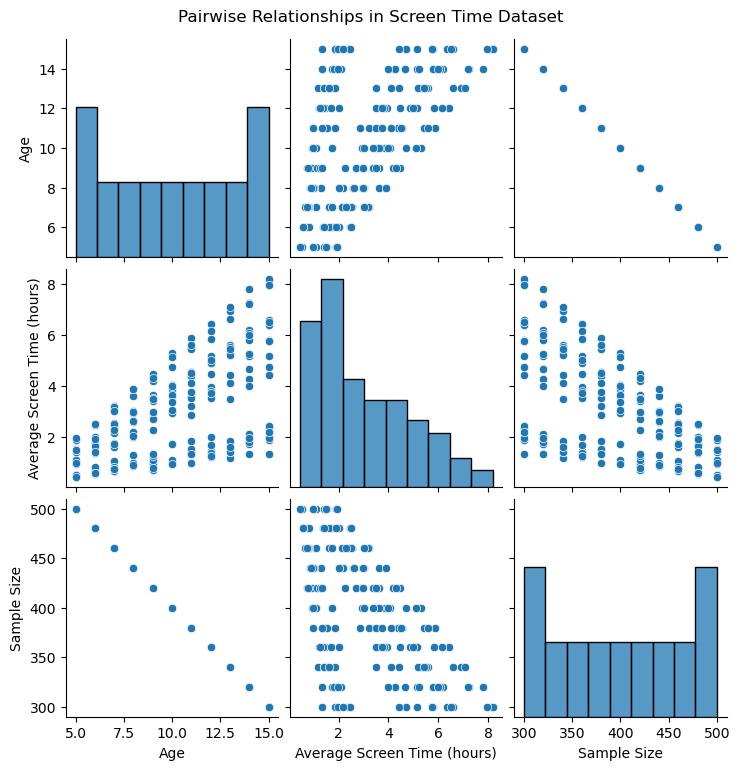

In [24]:
sns.pairplot(df)
plt.suptitle("Pairwise Relationships in Screen Time Dataset", y=1.02)
plt.show()

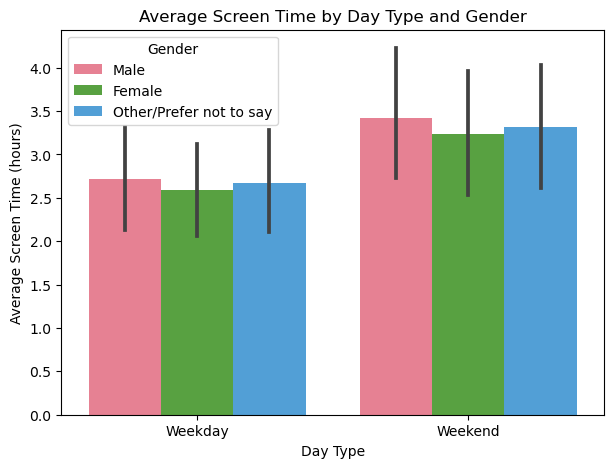

In [25]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='Day Type', y='Average Screen Time (hours)', hue='Gender', palette='husl')
plt.title("Average Screen Time by Day Type and Gender")
plt.xlabel("Day Type")
plt.ylabel("Average Screen Time (hours)")
plt.show()


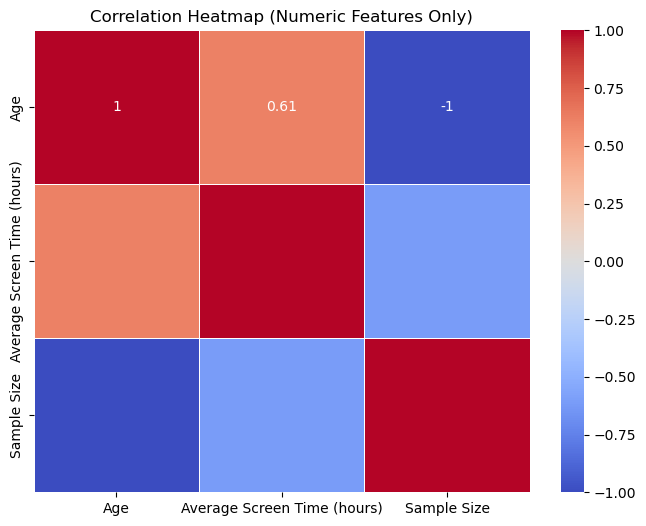

In [26]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

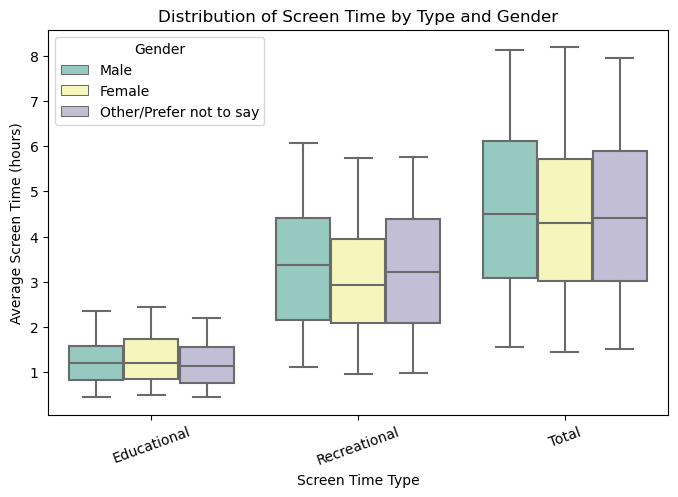

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Screen Time Type', y='Average Screen Time (hours)', hue='Gender', palette='Set3')
plt.title("Distribution of Screen Time by Type and Gender")
plt.xlabel("Screen Time Type")
plt.ylabel("Average Screen Time (hours)")
plt.xticks(rotation=20)
plt.show()
